In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [3]:
DATA_PATH   = r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv'
SERVER_IDS  = [1, 2, 3]

WORK_START  = 9    # 9 AM  (first forecast hour)
WORK_END    = 19   # exclusive → last forecast at 17:00
WORK_HOURS  = list(range(WORK_START, WORK_END))  # [9,10,...,17]
HORIZON     = len(WORK_HOURS)   # 9
LOOKBACK    = 24                # hours of lag history

PRED_DATE_ACTUAL  = pd.Timestamp('2026-06-10').date()   # compare forecast vs actuals
PRED_DATE_FUTURE  = pd.Timestamp('2026-06-11').date()   # forecast only (no actuals yet)

TARGET_COLS  = [f'cpu_t{h:02d}' for h in WORK_HOURS]   # cpu_t09 … cpu_t17
HOUR_LABELS  = [f'{h}:00' for h in WORK_HOURS]
print(f'Working hours: {WORK_HOURS[0]:02d}:00 → {WORK_HOURS[-1]:02d}:00  ({HORIZON} steps)')

Working hours: 09:00 → 18:00  (10 steps)


In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['ts'] = pd.to_datetime(df_raw['ts'], format='mixed', utc=True)
df_raw = df_raw.sort_values(['host_id', 'ts'])

print('All servers in data:', df_raw['host_id'].unique())
for sid in SERVER_IDS:
    sub = df_raw[df_raw['host_id']==sid]
    name = sub['hostName'].iloc[0]
    print(f'  Server {sid} ({name}): {len(sub):,} rows  '
          f'{sub["ts"].min().date()} → {sub["ts"].max().date()}')

All servers in data: [1 2 3]
  Server 1 (10.10.10.65): 24,750 rows  2026-04-02 → 2026-06-11
  Server 2 (10.10.10.150): 24,751 rows  2026-04-02 → 2026-06-11
  Server 3 (10.10.10.2): 24,751 rows  2026-04-02 → 2026-06-11


#### Feature engineering and dataset building

In [5]:
def build_features(df_server: pd.DataFrame) -> pd.DataFrame:
    """Resample → hourly and engineer all features for one server."""
    hourly = df_server.set_index('ts').resample('1h').agg(
        cpu_usage_pct        = ('cpu_usage_pct',        'mean'),
        cpu_min              = ('cpu_usage_pct',        'min'),
        cpu_max              = ('cpu_usage_pct',        'max'),
        cpu_std              = ('cpu_usage_pct',        'std'),
        memory_usage_pct     = ('memory_usage_pct',     'mean'),
        power_kw             = ('power_kw',             'mean'),
        cpu_temp_c           = ('cpu_temp_c',           'mean'),
        inlet_temp_c         = ('inlet_temp_c',         'mean'),
        resource_stress_index= ('resource_stress_index','mean'),
    ).dropna()

    # Temporal features
    hourly['hour_of_day'] = hourly.index.hour
    hourly['day_of_week'] = hourly.index.dayofweek
    hourly['is_weekend']  = (hourly['day_of_week'] >= 5).astype(int)
    hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour_of_day'] / 24)
    hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour_of_day'] / 24)
    hourly['dow_sin']  = np.sin(2 * np.pi * hourly['day_of_week'] / 7)
    hourly['dow_cos']  = np.cos(2 * np.pi * hourly['day_of_week'] / 7)

    # CPU lag history (24 hours)
    for lag in range(1, LOOKBACK + 1):
        hourly[f'cpu_lag_{lag}'] = hourly['cpu_usage_pct'].shift(lag)

    # Weekly anchor lags & delta
    hourly['cpu_lag_1w']        = hourly['cpu_usage_pct'].shift(168)
    hourly['cpu_lag_2w']        = hourly['cpu_usage_pct'].shift(336)
    hourly['cpu_vs_last_week']  = hourly['cpu_usage_pct'] - hourly['cpu_lag_1w']

    # Rolling statistics
    shifted = hourly['cpu_usage_pct'].shift(1)
    hourly['roll_mean_8h']  = shifted.rolling(8).mean()
    hourly['roll_mean_24h'] = shifted.rolling(24).mean()
    hourly['roll_std_8h']   = shifted.rolling(8).std()

    # 6-hour trend slope
    def rolling_slope(s, w=6):
        x = np.arange(w)
        return s.rolling(w).apply(
            lambda y: np.polyfit(x, y, 1)[0] if len(y)==w else np.nan, raw=True)
    hourly['cpu_trend_6h'] = rolling_slope(shifted)

    # Lagged system metrics
    for col in ['memory_usage_pct','power_kw','cpu_temp_c',
                'inlet_temp_c','resource_stress_index']:
        hourly[f'{col}_lag1'] = hourly[col].shift(1)

    return hourly.dropna()


FEATURE_COLS = (
    [f'cpu_lag_{i}' for i in range(1, LOOKBACK+1)] +
    ['cpu_lag_1w', 'cpu_lag_2w', 'cpu_vs_last_week',
     'roll_mean_8h', 'roll_mean_24h', 'roll_std_8h', 'cpu_trend_6h',
     'cpu_min', 'cpu_max', 'cpu_std',
     'memory_usage_pct_lag1', 'power_kw_lag1', 'cpu_temp_c_lag1',
     'inlet_temp_c_lag1', 'resource_stress_index_lag1',
     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
     'hour_of_day', 'day_of_week', 'is_weekend']
)
print(f'Feature count: {len(FEATURE_COLS)}')

Feature count: 46


In [6]:
def build_day_dataset(hourly: pd.DataFrame) -> pd.DataFrame:
    """
    For each calendar day: use the 8 AM hourly row as the prediction point,
    and the 9–17 rows as the 9 target values.
    """
    records = []
    for date in pd.Series(hourly.index.date).unique():
        day = hourly[hourly.index.date == date]
        pred_rows = day[day['hour_of_day'] == 8]
        if pred_rows.empty:
            continue
        pred_row = pred_rows.iloc[-1]
        targets, ok = {}, True
        for h in WORK_HOURS:
            t = day[day['hour_of_day'] == h]
            if t.empty: ok = False; break
            targets[f'cpu_t{h:02d}'] = t.iloc[0]['cpu_usage_pct']
        if not ok:
            continue
        row = {col: pred_row[col] for col in FEATURE_COLS}
        row.update(targets)
        row['pred_date'] = date
        records.append(row)
    return pd.DataFrame(records)

print('Helpers ready.')

Helpers ready.


#### Train a separate model for each server

In [7]:
server_data = {}   # stores hourly df per server
server_info = {}   # stores hostName per server
models      = {}   # trained model per server
datasets    = {}   # day-level dataset per server
test_sets   = {}   # (X_test, Y_test, test_df) per server
predictions = {}   # test-set predictions per server
metrics_all = {}   # per-hour metrics per server

for sid in SERVER_IDS:
    sub  = df_raw[df_raw['host_id'] == sid].copy()
    name = sub['hostName'].iloc[0]
    server_info[sid] = name
    print(f"\n{'='*60}")
    print(f'SERVER {sid}  |  {name}')
    print(f"{'='*60}")

    # Feature engineering
    hourly = build_features(sub)
    server_data[sid] = hourly

    # Day-level dataset
    ds = build_day_dataset(hourly)
    datasets[sid] = ds
    print(f'  Training days available: {len(ds)}')

    # Train/test split (80/20 chronological)
    split = int(len(ds) * 0.80)
    train_df = ds.iloc[:split]
    test_df  = ds.iloc[split:]
    X_train, Y_train = train_df[FEATURE_COLS], train_df[TARGET_COLS]
    X_test,  Y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COLS]
    test_sets[sid] = (X_test, Y_test, test_df)

    # Train
    mdl = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=800, max_depth=6, learning_rate=0.03,
            subsample=0.85, colsample_bytree=0.85,
            min_child_weight=3, gamma=0.1, reg_lambda=1.5,
            tree_method='hist', random_state=42
        ), n_jobs=-1
    )
    mdl.fit(X_train, Y_train)
    models[sid] = mdl

    # Evaluate
    preds = mdl.predict(X_test)
    predictions[sid] = preds

    rows = []
    for i, h in enumerate(WORK_HOURS):
        col = f'cpu_t{h:02d}'
        rows.append({
            'Hour' : f'{h:02d}:00',
            'MAE'  : mean_absolute_error(Y_test[col], preds[:,i]),
            'RMSE' : np.sqrt(mean_squared_error(Y_test[col], preds[:,i])),
            'R2'   : r2_score(Y_test[col], preds[:,i])
        })
    mdf = pd.DataFrame(rows)
    metrics_all[sid] = mdf
    print(f'  Mean MAE: {mdf["MAE"].mean():.3f}%   Mean R²: {mdf["R2"].mean():.3f}')

print('\nAll 3 servers trained.')


SERVER 1  |  10.10.10.65
  Training days available: 55
  Mean MAE: 0.989%   Mean R²: 0.038

SERVER 2  |  10.10.10.150
  Training days available: 55
  Mean MAE: 0.493%   Mean R²: -4.773

SERVER 3  |  10.10.10.2
  Training days available: 55
  Mean MAE: 0.899%   Mean R²: -0.210

All 3 servers trained.


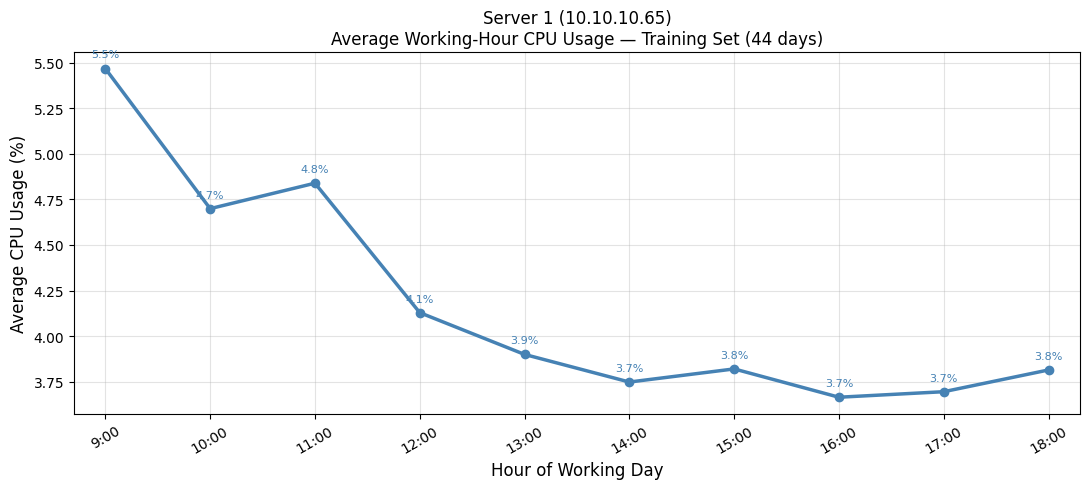

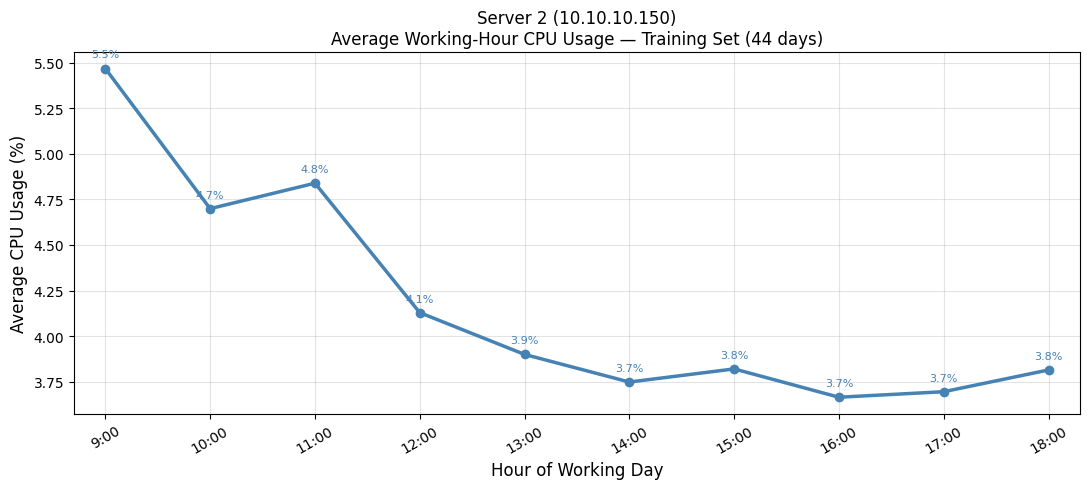

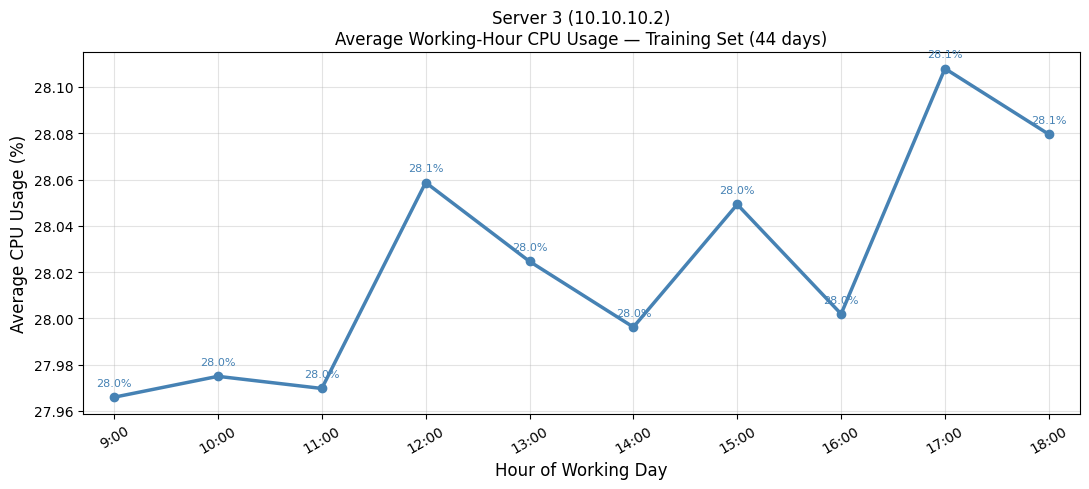

In [8]:
# Average cpu working hour profile
# ─────────────────────────────────────────────────────────────────────────────
# PLOT: Average working-hour CPU profile across the FULL TRAINING SET
# One separate figure per server, single line, x-axis = working hours
# ─────────────────────────────────────────────────────────────────────────────
for sid in SERVER_IDS:
    _, Y_test, test_df = test_sets[sid]
    name  = server_info[sid]
    ds    = datasets[sid]
    split = int(len(ds) * 0.80)
    train_df = ds.iloc[:split]

    # Average actual CPU per working hour across all training days
    avg_cpu = [train_df[f'cpu_t{h:02d}'].mean() for h in WORK_HOURS]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, avg_cpu, color='steelblue', marker='o', lw=2.5)
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('Average CPU Usage (%)', fontsize=12)
    ax.set_title(
        f'Server {sid} ({name})\n'
        f'Average Working-Hour CPU Usage — Training Set ({len(train_df)} days)',
        fontsize=12
    )
    ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)
    for x_val, y_val in zip(WORK_HOURS, avg_cpu):
        ax.annotate(f'{y_val:.1f}%', (x_val, y_val),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color='steelblue')
    plt.tight_layout()
    plt.show()

In [9]:
# June 10 - actual vs forecast
def get_8am_row(hourly, date):
    """Return the 8 AM hourly row for a given date, or None."""
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    return rows.iloc[-1] if not rows.empty else None

def get_working_actuals(hourly, date):
    """Return actual CPU values for each working hour on a given date."""
    day = hourly[hourly.index.date == date]
    vals = []
    for h in WORK_HOURS:
        row = day[day['hour_of_day'] == h]
        vals.append(row.iloc[0]['cpu_usage_pct'] if not row.empty else np.nan)
    return np.array(vals)

print('Helper functions ready.')

Helper functions ready.


In [10]:
import datetime

def get_best_pred_row(hourly, date):
    """
    Try 8 AM on the date first.
    Fall back to the latest pre-work row that day, then previous day's 8 AM.
    """
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{date} 08:00 (direct)'

    pre_work = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] < 9)]
    if not pre_work.empty:
        row = pre_work.iloc[-1]
        return row, f'{date} {int(row["hour_of_day"]):02d}:00 (latest pre-work)'

    prev = date - datetime.timedelta(days=1)
    rows = hourly[(hourly.index.date == prev) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{prev} 08:00 (prev-day proxy)'

    return None, 'No suitable prediction point found'

print('Fallback helper ready.')

Fallback helper ready.


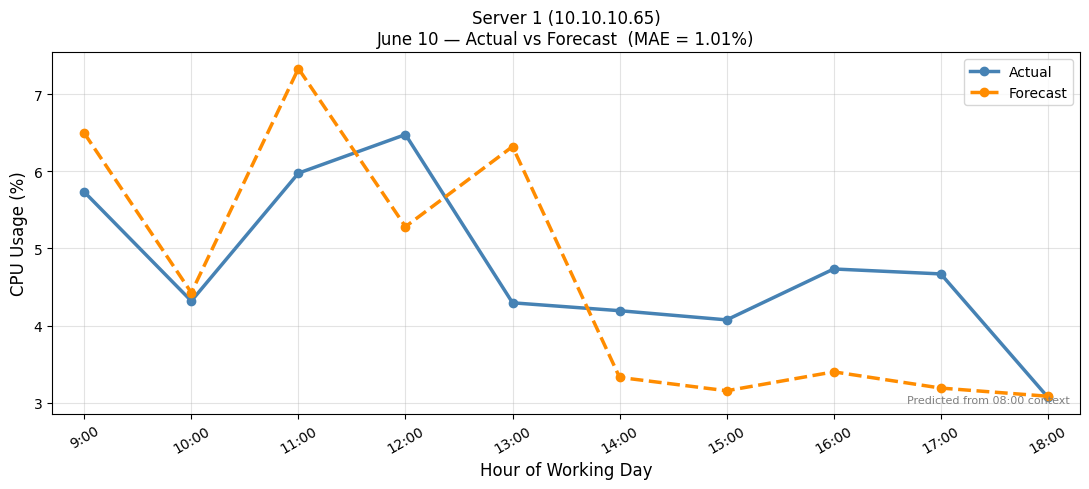

Server 1 June 10 | MAE=1.01% | 9:00 A=5.7 F=6.5 | 10:00 A=4.3 F=4.4 | 11:00 A=6.0 F=7.3 | 12:00 A=6.5 F=5.3 | 13:00 A=4.3 F=6.3 | 14:00 A=4.2 F=3.3 | 15:00 A=4.1 F=3.2 | 16:00 A=4.7 F=3.4 | 17:00 A=4.7 F=3.2 | 18:00 A=3.1 F=3.1


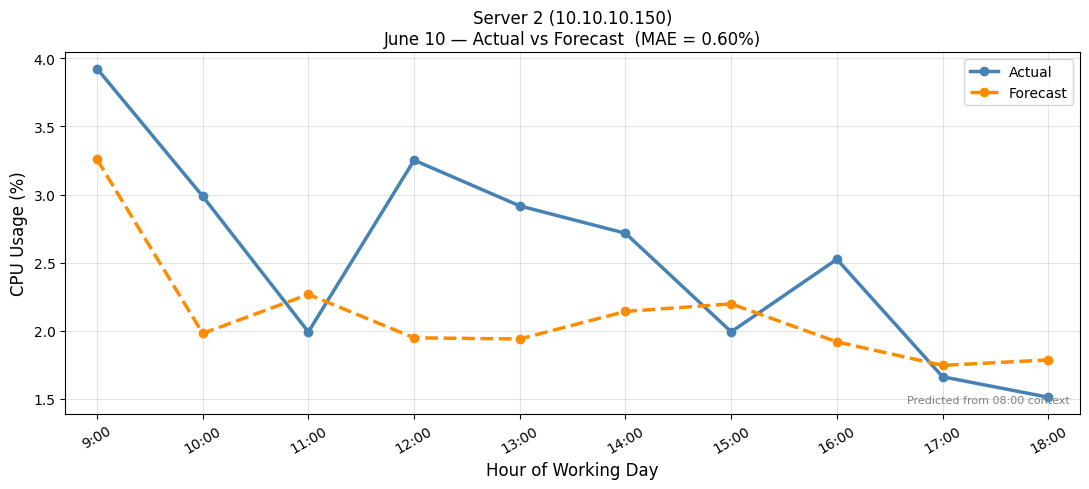

Server 2 June 10 | MAE=0.60% | 9:00 A=3.9 F=3.3 | 10:00 A=3.0 F=2.0 | 11:00 A=2.0 F=2.3 | 12:00 A=3.3 F=1.9 | 13:00 A=2.9 F=1.9 | 14:00 A=2.7 F=2.1 | 15:00 A=2.0 F=2.2 | 16:00 A=2.5 F=1.9 | 17:00 A=1.7 F=1.7 | 18:00 A=1.5 F=1.8


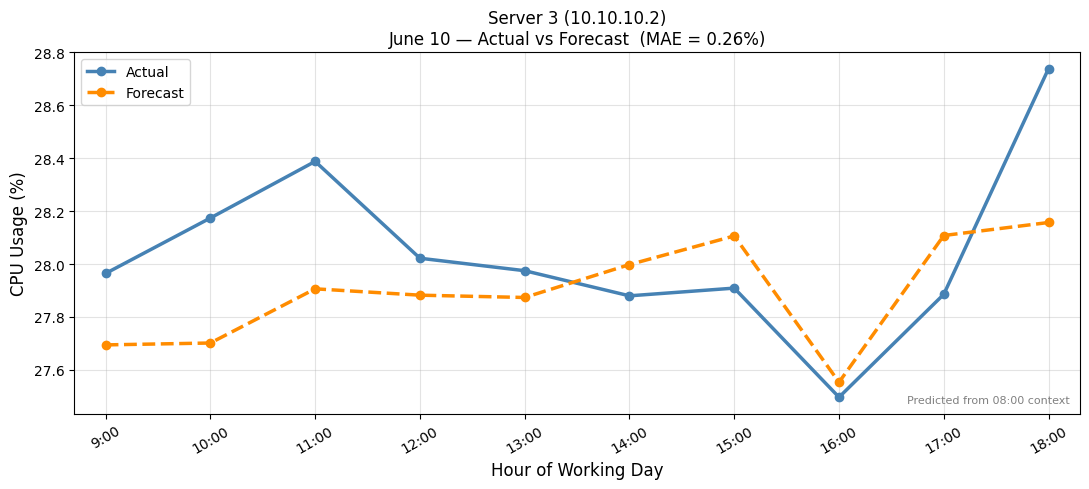

Server 3 June 10 | MAE=0.26% | 9:00 A=28.0 F=27.7 | 10:00 A=28.2 F=27.7 | 11:00 A=28.4 F=27.9 | 12:00 A=28.0 F=27.9 | 13:00 A=28.0 F=27.9 | 14:00 A=27.9 F=28.0 | 15:00 A=27.9 F=28.1 | 16:00 A=27.5 F=27.6 | 17:00 A=27.9 F=28.1 | 18:00 A=28.7 F=28.2


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT: June 10 — Actual vs Forecast, one separate figure per server
# ─────────────────────────────────────────────────────────────────────────────
june10_forecasts = {}

for sid in SERVER_IDS:
    hourly = server_data[sid]
    mdl    = models[sid]
    name   = server_info[sid]

    pred_row = get_8am_row(hourly, PRED_DATE_ACTUAL)
    if pred_row is None:
        print(f'Server {sid}: no 8 AM row for {PRED_DATE_ACTUAL}')
        continue

    X_infer  = pd.DataFrame([pred_row[FEATURE_COLS]])
    forecast = mdl.predict(X_infer)[0]
    actuals  = get_working_actuals(hourly, PRED_DATE_ACTUAL)
    june10_forecasts[sid] = forecast

    mae = np.nanmean(np.abs(forecast - actuals))

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, actuals,  color='steelblue',  marker='o', lw=2.5, label='Actual')
    ax.plot(WORK_HOURS, forecast, color='darkorange',  marker='o', lw=2.5,
            linestyle='--', label='Forecast')
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('CPU Usage (%)', fontsize=12)
    ax.set_title(
        f'Server {sid} ({name})\n'
        f'June 10 — Actual vs Forecast  (MAE = {mae:.2f}%)',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)
    ax.text(0.99, 0.03, f'Predicted from 08:00 context',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

    print(f'Server {sid} June 10 | MAE={mae:.2f}% | '
          + ' | '.join([f'{h}:00 A={a:.1f} F={f:.1f}'
                        for h,a,f in zip(WORK_HOURS, actuals, forecast)]))

#### June 11 Forecast

In [12]:
# June 11 - forecast only
def get_best_pred_row(hourly, date):
    """
    Try to get the 8 AM row for the date.
    If unavailable (data not yet there), fall back to the last available row
    before working hours begin, using the previous day's 8 AM as a proxy.
    """
    # Try 8 AM on the actual date
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{date} 08:00 (direct)'

    # Fall back: latest available row before 9 AM for that date
    pre_work = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] < 9)]
    if not pre_work.empty:
        row = pre_work.iloc[-1]
        return row, f'{date} {int(row["hour_of_day"]):02d}:00 (latest pre-work)'

    # Fall back: previous day's 8 AM
    import datetime
    prev = date - datetime.timedelta(days=1)
    rows = hourly[(hourly.index.date == prev) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{prev} 08:00 (prev-day proxy)'

    return None, 'No suitable prediction point found'

print('Fallback helper ready.')

Fallback helper ready.


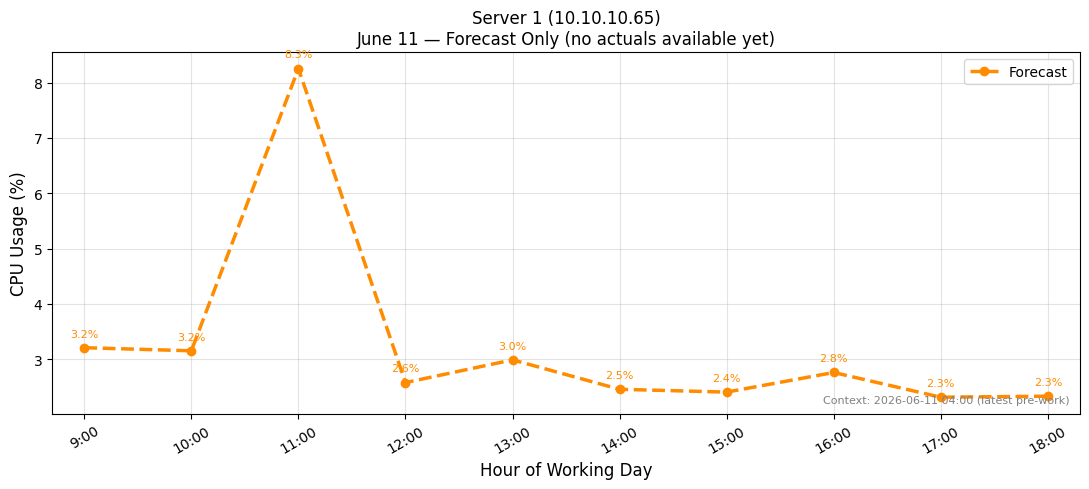

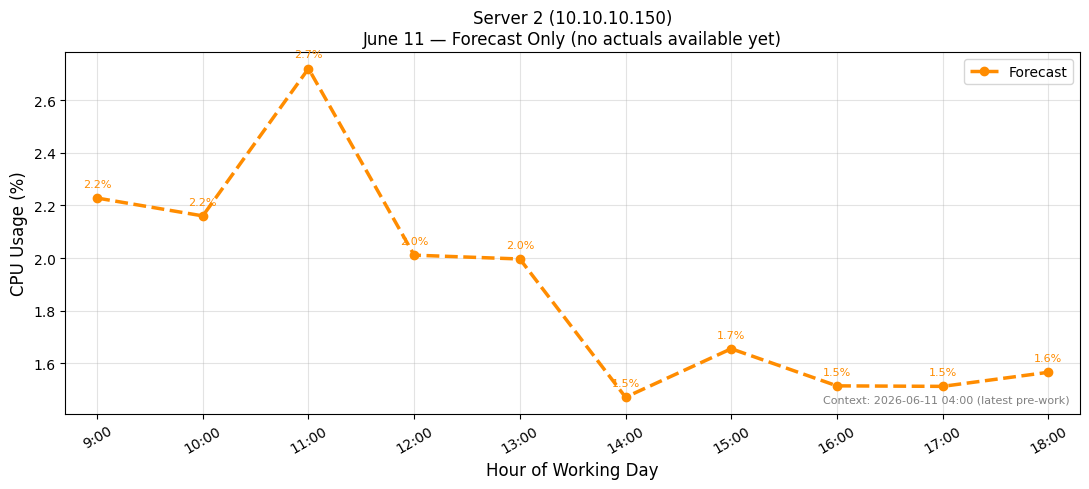

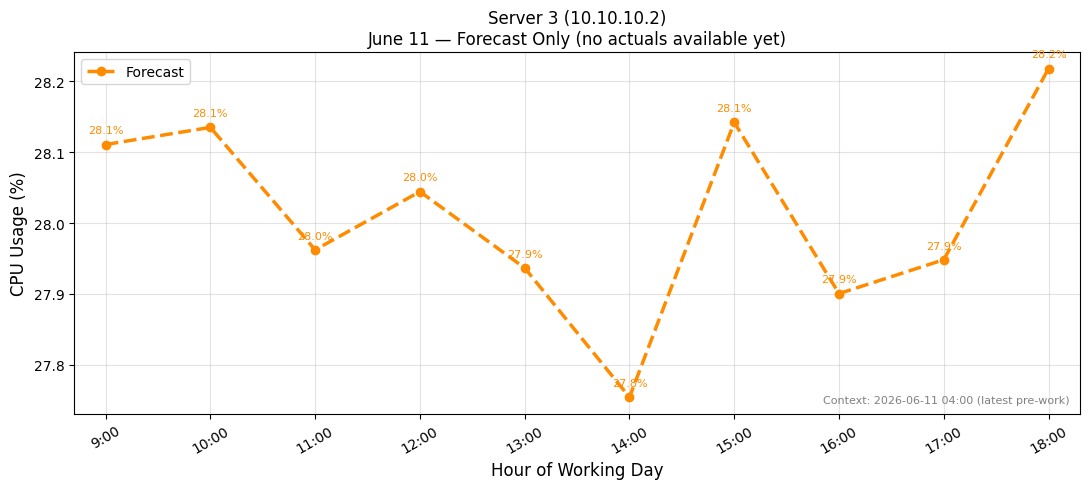

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT: June 11 — Forecast Only, one separate figure per server
# ─────────────────────────────────────────────────────────────────────────────
june11_forecasts = {}

for sid in SERVER_IDS:
    hourly = server_data[sid]
    mdl    = models[sid]
    name   = server_info[sid]

    pred_row, ctx_label = get_best_pred_row(hourly, PRED_DATE_FUTURE)
    if pred_row is None:
        print(f'Server {sid}: no prediction point found')
        continue

    X_infer  = pd.DataFrame([pred_row[FEATURE_COLS]])
    forecast = mdl.predict(X_infer)[0]
    june11_forecasts[sid] = forecast

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, forecast, color='darkorange', marker='o', lw=2.5,
            linestyle='--', label='Forecast')
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('CPU Usage (%)', fontsize=12)
    ax.set_title(
        f'Server {sid} ({name})\n'
        f'June 11 — Forecast Only (no actuals available yet)',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)
    ax.text(0.99, 0.03, f'Context: {ctx_label}',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')
    for x_val, y_val in zip(WORK_HOURS, forecast):
        ax.annotate(f'{y_val:.1f}%', (x_val, y_val),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color='darkorange')
    plt.tight_layout()
    plt.show()

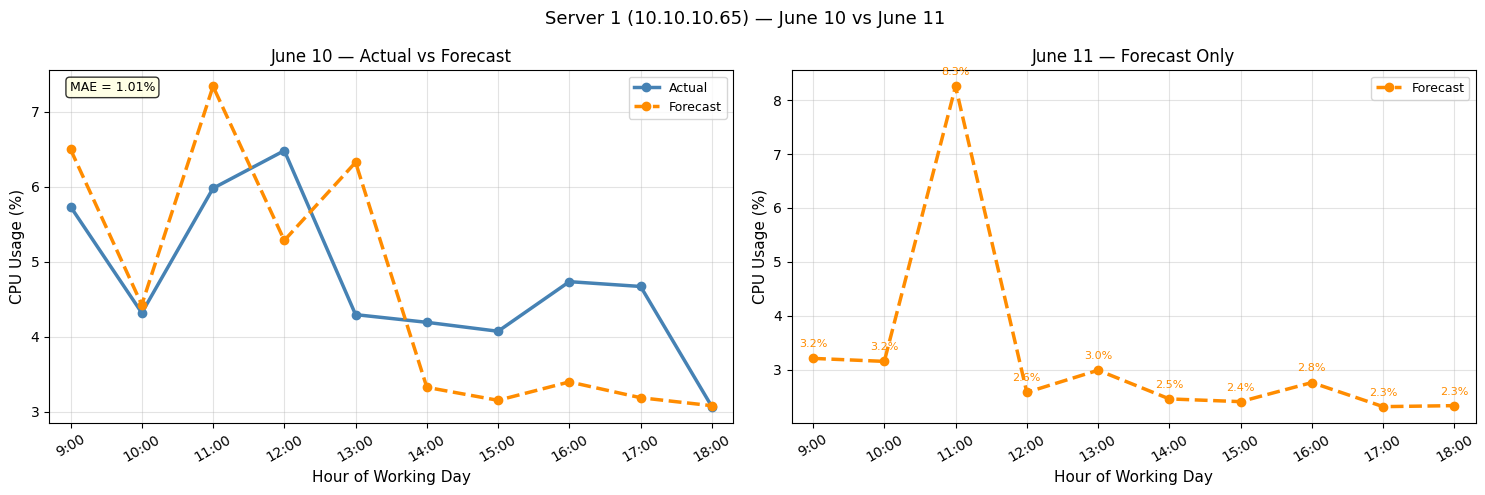

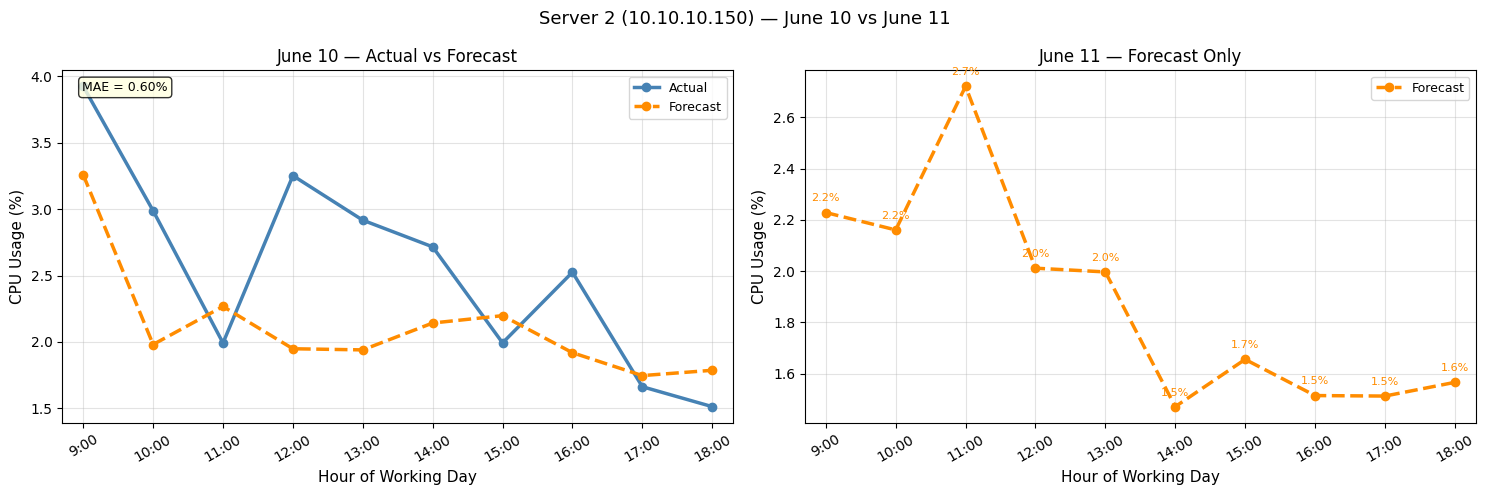

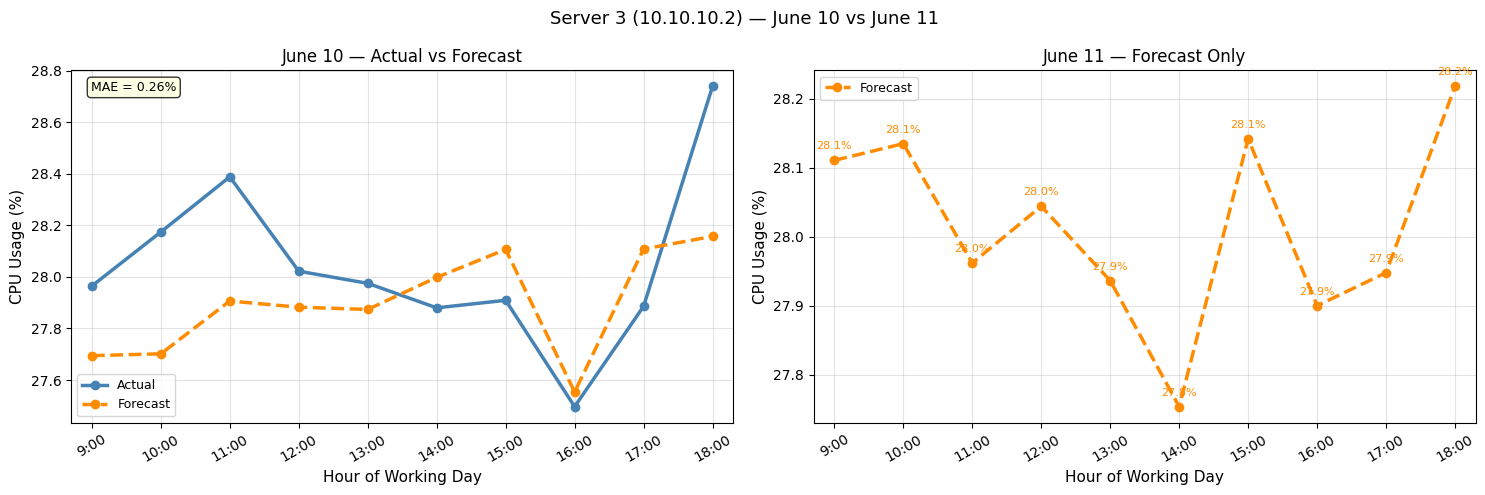

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY: June 10 vs June 11 side-by-side — one figure per server
# ─────────────────────────────────────────────────────────────────────────────
for sid in SERVER_IDS:
    hourly = server_data[sid]
    mdl    = models[sid]
    name   = server_info[sid]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── Left: June 10 actual vs forecast ──────────────────────────────────
    ax10 = axes[0]
    pr10 = get_8am_row(hourly, PRED_DATE_ACTUAL)
    if pr10 is not None:
        fc10  = mdl.predict(pd.DataFrame([pr10[FEATURE_COLS]]))[0]
        act10 = get_working_actuals(hourly, PRED_DATE_ACTUAL)
        mae10 = np.nanmean(np.abs(fc10 - act10))
        ax10.plot(WORK_HOURS, act10, color='steelblue', marker='o', lw=2.5, label='Actual')
        ax10.plot(WORK_HOURS, fc10,  color='darkorange', marker='o', lw=2.5,
                  linestyle='--', label='Forecast')
        ax10.text(0.03, 0.97, f'MAE = {mae10:.2f}%', transform=ax10.transAxes,
                  va='top', fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    ax10.set_xticks(WORK_HOURS); ax10.set_xticklabels(HOUR_LABELS, rotation=30)
    ax10.set_xlabel('Hour of Working Day', fontsize=11)
    ax10.set_ylabel('CPU Usage (%)', fontsize=11)
    ax10.set_title(f'June 10 — Actual vs Forecast', fontsize=12)
    ax10.legend(fontsize=9); ax10.grid(True, alpha=0.35)
    ax10.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)

    # ── Right: June 11 forecast only ──────────────────────────────────────
    ax11 = axes[1]
    if sid in june11_forecasts:
        fc11 = june11_forecasts[sid]
        ax11.plot(WORK_HOURS, fc11, color='darkorange', marker='o', lw=2.5,
                  linestyle='--', label='Forecast')
        for x_val, y_val in zip(WORK_HOURS, fc11):
            ax11.annotate(f'{y_val:.1f}%', (x_val, y_val),
                          textcoords='offset points', xytext=(0, 8),
                          ha='center', fontsize=8, color='darkorange')
    ax11.set_xticks(WORK_HOURS); ax11.set_xticklabels(HOUR_LABELS, rotation=30)
    ax11.set_xlabel('Hour of Working Day', fontsize=11)
    ax11.set_ylabel('CPU Usage (%)', fontsize=11)
    ax11.set_title(f'June 11 — Forecast Only', fontsize=12)
    ax11.legend(fontsize=9); ax11.grid(True, alpha=0.35)
    ax11.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)

    fig.suptitle(f'Server {sid} ({name}) — June 10 vs June 11', fontsize=13)
    plt.tight_layout()
    plt.show()

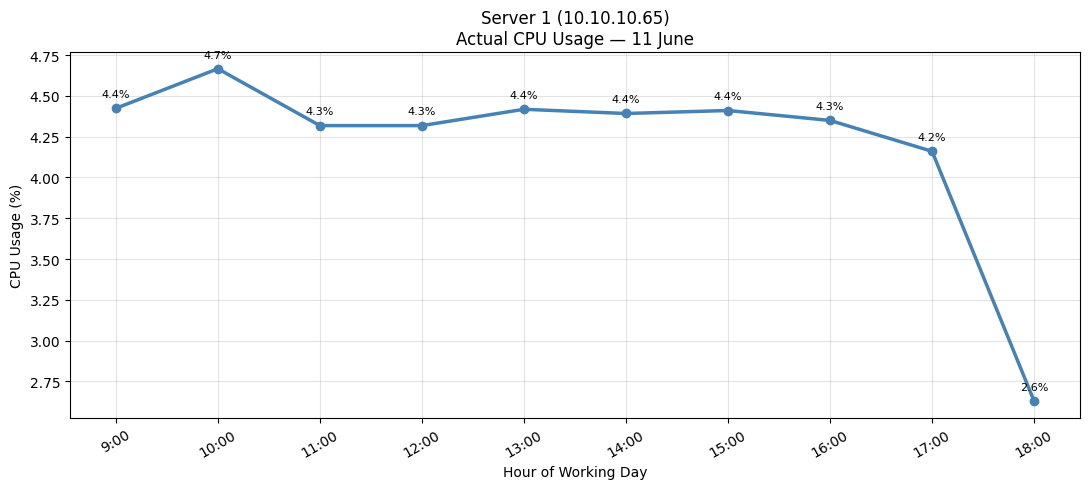

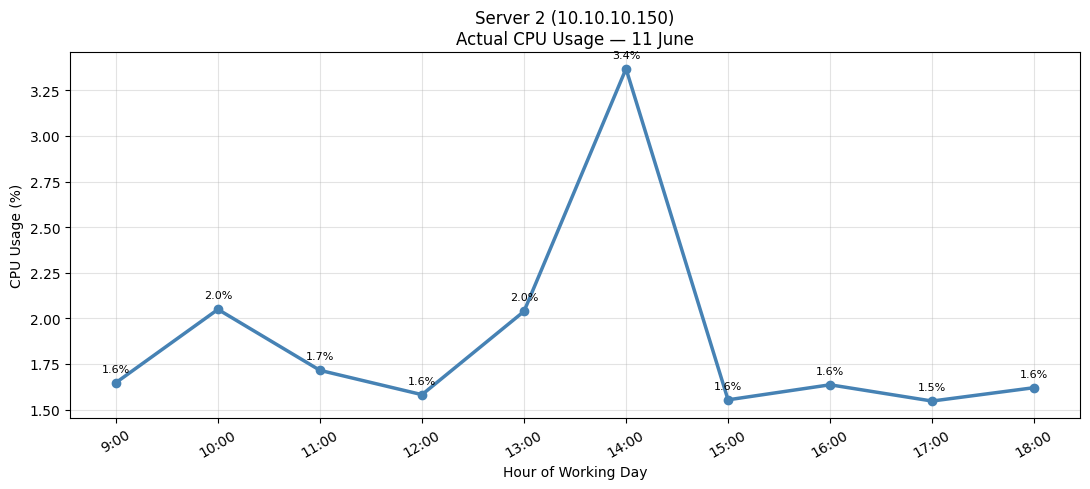

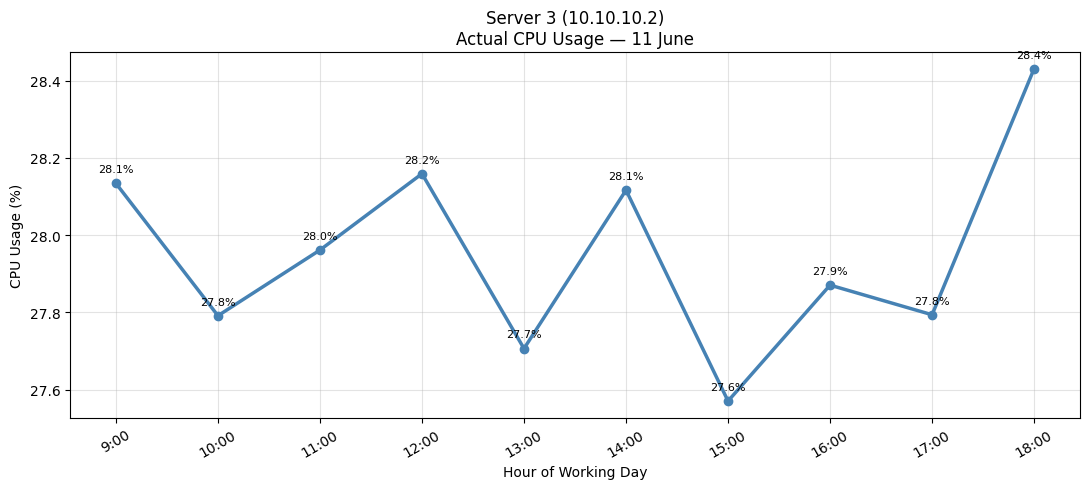

In [16]:
# =============================================================================
# ACTUAL CPU Usage — 11 June (from new baseline dataset)
# =============================================================================

NEW_BASELINE_PATH = r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline_new.csv"

actual_df = pd.read_csv(NEW_BASELINE_PATH)

actual_df["ts"] = pd.to_datetime(actual_df["ts"], format="mixed", utc=True)
actual_df["ts"] = actual_df["ts"].dt.tz_localize(None)

TARGET_DATE = pd.Timestamp("2026-06-11").date()

actual_hourly = (
    actual_df
    .set_index("ts")
    .groupby("host_id")
    .resample("1H")["cpu_usage_pct"]
    .mean()
    .reset_index()
)

actual_hourly["hour_of_day"] = actual_hourly["ts"].dt.hour

actual_june11 = {}

for sid in SERVER_IDS:

    server = actual_hourly[
        (actual_hourly.host_id == sid) &
        (actual_hourly.ts.dt.date == TARGET_DATE) &
        (actual_hourly.hour_of_day.isin(WORK_HOURS))
    ].sort_values("hour_of_day")

    cpu = []

    for h in WORK_HOURS:
        row = server[server.hour_of_day == h]
        cpu.append(row.cpu_usage_pct.iloc[0] if not row.empty else np.nan)

    actual_june11[sid] = np.array(cpu)

    fig, ax = plt.subplots(figsize=(11,5))

    ax.plot(
        WORK_HOURS,
        cpu,
        marker="o",
        linewidth=2.5,
        color="steelblue"
    )

    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)

    ax.set_xlabel("Hour of Working Day")
    ax.set_ylabel("CPU Usage (%)")

    ax.set_title(
        f"Server {sid} ({server_info[sid]})\n"
        "Actual CPU Usage — 11 June"
    )

    ax.grid(True, alpha=0.35)

    for x,y in zip(WORK_HOURS,cpu):
        if not np.isnan(y):
            ax.annotate(
                f"{y:.1f}%",
                (x,y),
                textcoords="offset points",
                xytext=(0,8),
                ha="center",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

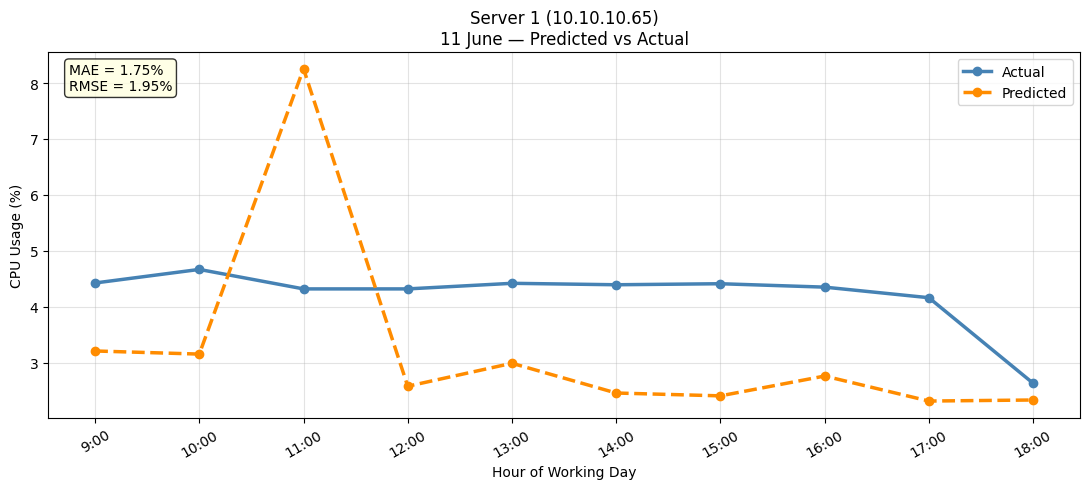

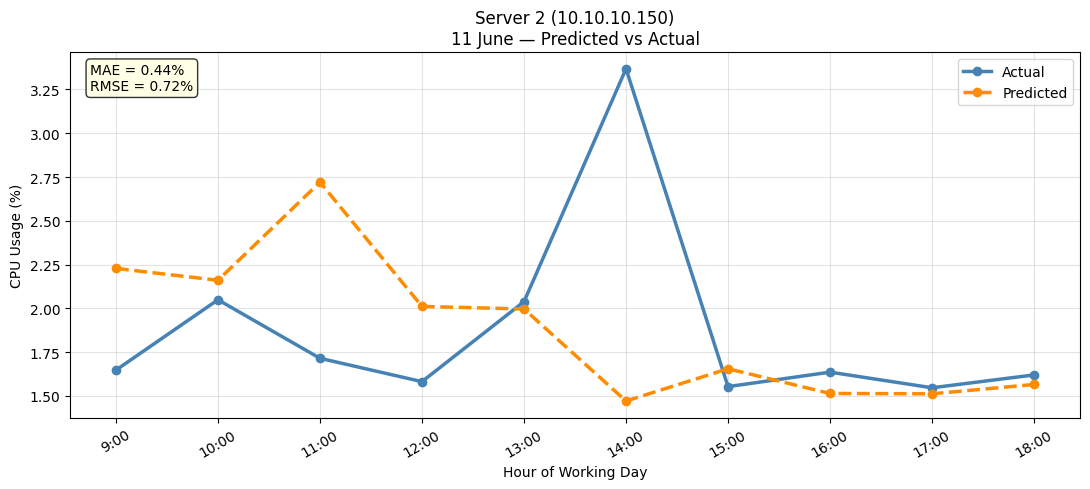

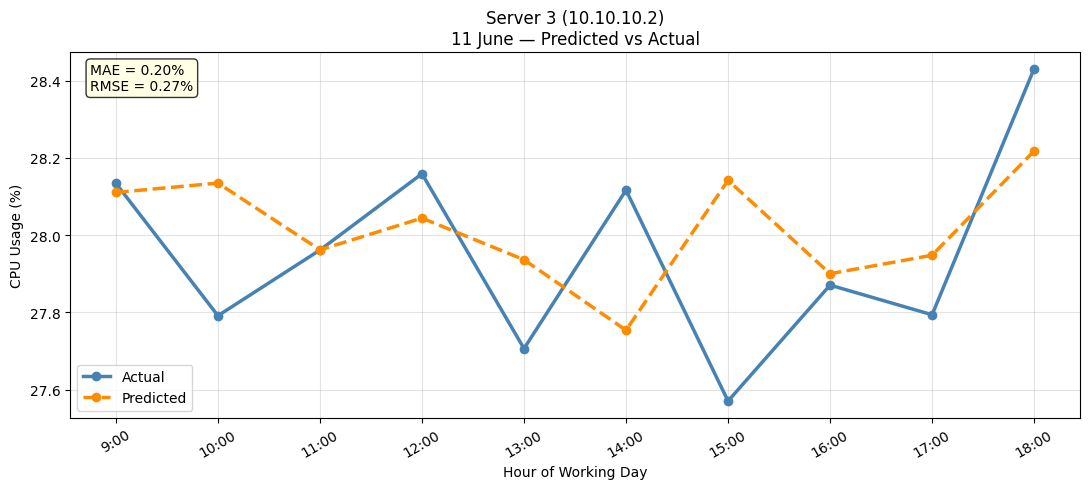

In [17]:
# =============================================================================
# June 11 Comparison
# Previous Prediction vs Actual
# =============================================================================

for sid in SERVER_IDS:

    pred = june11_forecasts[sid]
    actual = actual_june11[sid]

    mae = np.nanmean(np.abs(pred - actual))
    rmse = np.sqrt(np.nanmean((pred - actual) ** 2))

    fig, ax = plt.subplots(figsize=(11,5))

    ax.plot(
        WORK_HOURS,
        actual,
        marker="o",
        linewidth=2.5,
        color="steelblue",
        label="Actual"
    )

    ax.plot(
        WORK_HOURS,
        pred,
        marker="o",
        linestyle="--",
        linewidth=2.5,
        color="darkorange",
        label="Predicted"
    )

    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)

    ax.set_xlabel("Hour of Working Day")
    ax.set_ylabel("CPU Usage (%)")

    ax.set_title(
        f"Server {sid} ({server_info[sid]})\n"
        "11 June — Predicted vs Actual"
    )

    ax.grid(True, alpha=0.35)
    ax.legend()

    ax.text(
        0.02,
        0.97,
        f"MAE = {mae:.2f}%\nRMSE = {rmse:.2f}%",
        transform=ax.transAxes,
        va="top",
        bbox=dict(
            facecolor="lightyellow",
            alpha=0.8,
            boxstyle="round"
        )
    )

    plt.tight_layout()
    plt.show()

In [18]:
# =============================================================================
# Forecast Performance Metrics (11 June)
# =============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    max_error
)

results = []

print("="*80)
print("FORECAST PERFORMANCE - 11 JUNE")
print("="*80)

for sid in SERVER_IDS:

    actual = actual_june11[sid]
    pred = june11_forecasts[sid]

    # Remove NaN values (if any)
    mask = ~np.isnan(actual)

    actual_clean = actual[mask]
    pred_clean = pred[mask]

    mae = mean_absolute_error(actual_clean, pred_clean)
    rmse = np.sqrt(mean_squared_error(actual_clean, pred_clean))
    mape = np.mean(np.abs((actual_clean - pred_clean) / actual_clean)) * 100
    r2 = r2_score(actual_clean, pred_clean)
    maxerr = max_error(actual_clean, pred_clean)

    results.append({
        "Server": sid,
        "Hostname": server_info[sid],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2,
        "Max Error": maxerr
    })

    print(f"\nServer {sid} ({server_info[sid]})")
    print("-"*60)
    print(f"MAE       : {mae:.2f}")
    print(f"RMSE      : {rmse:.2f}")
    print(f"MAPE      : {mape:.2f}%")
    print(f"R² Score  : {r2:.4f}")
    print(f"Max Error : {maxerr:.2f}")

metrics_df = pd.DataFrame(results)

print("\n")
print("="*80)
print(metrics_df.round(3))

FORECAST PERFORMANCE - 11 JUNE

Server 1 (10.10.10.65)
------------------------------------------------------------
MAE       : 1.75
RMSE      : 1.95
MAPE      : 40.58%
R² Score  : -12.1129
Max Error : 3.94

Server 2 (10.10.10.150)
------------------------------------------------------------
MAE       : 0.44
RMSE      : 0.72
MAPE      : 20.44%
R² Score  : -0.8596
Max Error : 1.90

Server 3 (10.10.10.2)
------------------------------------------------------------
MAE       : 0.20
RMSE      : 0.27
MAPE      : 0.73%
R² Score  : -0.1962
Max Error : 0.57


   Server      Hostname    MAE   RMSE  MAPE (%)      R²  Max Error
0       1   10.10.10.65  1.752  1.954    40.585 -12.113      3.938
1       2  10.10.10.150  0.438  0.720    20.444  -0.860      1.897
2       3    10.10.10.2  0.204  0.267     0.733  -0.196      0.571
